# Mapper v4.1 — contract-scale mixed dataset

Этот ноутбук заменяет старую `v4_01` логику с percentile scaling.

Главная фиксация:

```text
z8_scaled теперь означает contract-scale, а не percentile-scale.
```

То есть:

```text
bass raw = -2 dB при extreme bass = 14 dB → z_bass ≈ -0.29
bass raw = -14 dB → z_bass = -2
bass raw = +14 dB → z_bass = +2
```

В конце ноутбук собирает датасет для обучения mapper-а:

```text
SocialFX / OPRA / external real curves
+ synthetic contract axis sweeps
+ synthetic archetypes
+ synthetic safe random profiles
```

Сохраняется тот же файл, который читает train notebook:

```text
outputs/mapper_v4_scale_aligned_dataset.parquet
outputs/mapper_v4_feature_scale_normalizer.json
```

Но по смыслу это уже `contract-aligned dataset`.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Allow running from notebooks/ or mapper_v2/.
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR
for p in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    if (p / "research" / "mapper_v2").exists():
        PROJECT_ROOT = p
        break

MAPPER_DIR = PROJECT_ROOT / "research" / "mapper_v2"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(MAPPER_DIR) not in sys.path:
    sys.path.insert(0, str(MAPPER_DIR))

from research.mapper_v2 import feature_space as fs
from research.mapper_v2 import mapper_io as mio
from research.mapper_v2 import mapper_basis as mb


DIRS = mio.ensure_dirs(MAPPER_DIR)
OUTPUT_DIR = DIRS["outputs"]
FIGURES_DIR = DIRS["figures"]
TABLES_DIR = DIRS["tables"]

mp.use_article_style()
print("PROJECT_ROOT:", PROJECT_ROOT)
print("MAPPER_DIR:", MAPPER_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_ROOT: C:\Users\makcc\PycharmProjects\EarLoop
MAPPER_DIR: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2
OUTPUT_DIR: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs


## 1. Contract scale

Здесь задаём явный смысл `z=±2` в dB, а не через percentiles датасета.

Можно менять эти значения, но это уже будет изменение scale contract для всей системы.

In [5]:
CONTRACT_EXTREME_DB = {
    "sub_bass": 16.0,
    "bass": 14.0,
    "lowmid": 6.0,
    "warmth": 6.0,
    "presence": 5.0,
    "clarity": 7.0,
    "air": 12.0,
    "brightness": 8.0,
}

SYNTHETIC_FRACTION_OF_REAL = 0.05
SYNTHETIC_MAX_RANDOM = 750

SYNTHETIC_ARCHETYPE_JITTER_N = 2000

SYNTHETIC_RANDOM_N = None
SYNTHETIC_RANDOM_SIGMA = 0.65
SYNTHETIC_RANDOM_EXTREME_PROB = 0.20

ARCHETYPE_JITTER_SIGMA = 0.22
ARCHETYPE_STRENGTH_JITTER = 0.18

MAX_REAL_ROWS_PER_GROUP = None
SEED = 42

contract_table = pd.DataFrame({
    "feature": fs.FEATURE_NAMES_8D,
    "extreme_raw_db_for_abs_z_2": [CONTRACT_EXTREME_DB[n] for n in fs.FEATURE_NAMES_8D],
    "raw_db_per_1_z_unit": [CONTRACT_EXTREME_DB[n] / 2.0 for n in fs.FEATURE_NAMES_8D],
})
contract_table

,feature,extreme_raw_db_for_abs_z_2,raw_db_per_1_z_unit
0,sub_bass,16.0,8.0
1,bass,14.0,7.0
2,lowmid,6.0,3.0
3,warmth,6.0,3.0
4,presence,5.0,2.5
5,clarity,7.0,3.5
6,air,12.0,6.0
7,brightness,8.0,4.0


## 2. Load available real mapper sources

Loader ищет curve-datasets в `outputs/` и `outputs/tables/`. Feature-only таблицы пропускаются.

In [3]:
df_real_raw, freqs_23 = mio.load_available_mapper_sources(OUTPUT_DIR, verbose=True)

# Keep source_group explicit for diagnostics.
df_real_raw = df_real_raw.copy()
if "source_group" not in df_real_raw.columns:
    df_real_raw["source_group"] = df_real_raw.apply(mio.infer_source_group, axis=1)

print("real rows:", len(df_real_raw))
print("freqs:", freqs_23)
print("curve range:", float(np.min(np.stack(df_real_raw["curve_23"]))), float(np.max(np.stack(df_real_raw["curve_23"]))))
df_real_raw["source_group"].value_counts(dropna=False)

Loaded mapper curve datasets: ['opra_eq_profiles.parquet', 'socialfx_curves_with_8d.parquet']
Skipped non-curve/invalid files: opra_eq_profiles_with_8d.parquet (excluded by pattern), external_eq_profiles_with_8d.parquet (excluded by pattern), external_eq_profiles.parquet (excluded by pattern), combined_8d_features.parquet (excluded by pattern), socialfx_opra_8d_features.parquet (excluded by pattern), socialfx_curves_with_6d.parquet (excluded by pattern)...
real rows: 14188
freqs: [   20.            50.            83.           120.
   159.51029968   200.04376221   254.04821777   308.56271362
   383.           443.86398315   622.04351807   798.06713867
  1000.          1485.98254395  1875.          2368.08081055
  3389.64819336  4365.36328125  6934.26074219  8568.99511719
 12000.         14000.         16000.        ]
curve range: -19.9257869720459 19.9257869720459


source_group
opra        12593
socialfx     1595
Name: count, dtype: int64

## 3. Build contract-aligned mixed dataset

Важное отличие от старой версии:

```text
normalizer = FeatureScaleNormalizer.fit_contract(...)
```

А не:

```text
fit_percentile(p5, p95)
```

После этого `z8_scaled_vector` — это contract-scale вход для mapper-а.

In [6]:
mixed_df, normalizer = mio.build_mixed_contract_dataset(
    df_real_raw,
    freqs=freqs_23,
    extreme_db=CONTRACT_EXTREME_DB,
    synthetic_random_n=SYNTHETIC_RANDOM_N,
    synthetic_fraction_of_real=SYNTHETIC_FRACTION_OF_REAL,
    synthetic_max_random=SYNTHETIC_MAX_RANDOM,
    synthetic_archetype_jitter_n=SYNTHETIC_ARCHETYPE_JITTER_N,
    synthetic_random_sigma=SYNTHETIC_RANDOM_SIGMA,
    synthetic_random_extreme_prob=SYNTHETIC_RANDOM_EXTREME_PROB,
    archetype_jitter_sigma=ARCHETYPE_JITTER_SIGMA,
    archetype_strength_jitter=ARCHETYPE_STRENGTH_JITTER,
    seed=SEED,
    max_real_rows_per_group=MAX_REAL_ROWS_PER_GROUP,
)

print("mixed rows:", len(mixed_df))
print("normalizer method:", normalizer.fit_info.get("method") if normalizer.fit_info else None)

source_summary = (
    mixed_df
    .groupby(["source_group", "is_synthetic"])
    .size()
    .reset_index(name="rows")
)

source_summary["share_pct"] = 100 * source_summary["rows"] / len(mixed_df)
source_summary.sort_values("rows", ascending=False)

mixed rows: 16968
normalizer method: contract_db


,source_group,is_synthetic,rows,share_pct
0,opra,False,12593,74.216172
3,synthetic_archetype_jitter,True,2000,11.786893
1,socialfx,False,1595,9.400047
5,synthetic_random,True,709,4.178454
4,synthetic_axis,True,64,0.377181
2,synthetic_archetype,True,7,0.041254


In [8]:
# ==== Synthetic source diagnostics ====

curve_stats = []

for source_group, g in mixed_df.groupby("source_group"):
    curves = np.stack(g["curve_23"].values).astype(np.float32)
    max_abs = np.max(np.abs(curves), axis=1)

    curve_stats.append({
        "source_group": source_group,
        "rows": len(g),
        "mean_abs_db": float(np.mean(np.abs(curves))),
        "mean_max_abs_db": float(np.mean(max_abs)),
        "p95_max_abs_db": float(np.percentile(max_abs, 95)),
        "max_abs_db": float(np.max(max_abs)),
    })

source_curve_stats = (
    pd.DataFrame(curve_stats)
    .sort_values("mean_max_abs_db", ascending=False)
)

source_curve_stats

,source_group,rows,mean_abs_db,mean_max_abs_db,p95_max_abs_db,max_abs_db
3,synthetic_archetype_jitter,2000,4.488358,9.967907,15.946220,16.000000
2,synthetic_archetype,7,4.518878,9.856592,15.009153,15.045159
5,synthetic_random,709,2.908632,7.661195,11.938205,15.298779
4,synthetic_axis,64,1.206174,5.483063,11.174770,12.605610
0,opra,12593,1.097051,5.302817,10.574081,19.925787
1,socialfx,1595,0.906375,1.920107,2.407842,3.459269


In [9]:
# ==== Contract z coverage by source ====

z_rows = []

for source_group, g in mixed_df.groupby("source_group"):
    z = np.stack(g["z8_scaled_vector"].values).astype(np.float32)
    z_abs_max = np.max(np.abs(z), axis=1)

    z_rows.append({
        "source_group": source_group,
        "rows": len(g),
        "mean_abs_z": float(np.mean(np.abs(z))),
        "mean_max_abs_z": float(np.mean(z_abs_max)),
        "p95_max_abs_z": float(np.percentile(z_abs_max, 95)),
        "max_abs_z": float(np.max(z_abs_max)),
    })

source_z_stats = (
    pd.DataFrame(z_rows)
    .sort_values("mean_max_abs_z", ascending=False)
)

source_z_stats

,source_group,rows,mean_abs_z,mean_max_abs_z,p95_max_abs_z,max_abs_z
3,synthetic_archetype_jitter,2000,0.593258,1.286709,1.996982,2.000000
4,synthetic_axis,64,0.156250,1.250000,2.000000,2.000000
2,synthetic_archetype,7,0.579464,1.242857,1.620000,1.650000
5,synthetic_random,709,0.538640,1.220906,1.939532,2.000000
0,opra,12593,0.232876,0.657055,1.399219,2.000000
1,socialfx,1595,0.194742,0.400917,0.517023,0.561752


## 4. Sanity check: small dB correction should not become z=±2

Это ключевая проверка. Если `bass raw ≈ -2 dB`, то при `extreme bass = 14 dB` должно быть примерно:

```text
z_bass = 2 * (-2 / 14) ≈ -0.29
```

In [7]:
# Pick a real row with non-trivial but not huge EQ curve.
real_part = mixed_df[mixed_df["is_synthetic"] == False].copy()
curves_real = np.stack(real_part["curve_23"].values)
example_idx = int(np.argsort(np.max(np.abs(curves_real), axis=1))[len(curves_real) // 2])
example = real_part.iloc[example_idx]

z_raw = np.asarray(example["z8_raw_vector"], dtype=np.float32)
z_scaled = np.asarray(example["z8_scaled_vector"], dtype=np.float32)

pd.DataFrame({
    "feature": fs.FEATURE_NAMES_8D,
    "z8_raw_weighted_db": z_raw,
    "contract_extreme_db_for_abs_z_2": [CONTRACT_EXTREME_DB[n] for n in fs.FEATURE_NAMES_8D],
    "z8_contract_scaled": z_scaled,
}).sort_values("z8_contract_scaled")

,feature,z8_raw_weighted_db,contract_extreme_db_for_abs_z_2,z8_contract_scaled
0,sub_bass,-3.925714,16.0,-0.490714
1,bass,-1.589980,14.0,-0.227140
2,lowmid,-0.180052,6.0,-0.060017
3,warmth,-0.025751,6.0,-0.008584
4,presence,0.030381,5.0,0.012152
5,clarity,0.301111,7.0,0.086032
6,air,0.793001,12.0,0.132167
7,brightness,2.233042,8.0,0.558260


## 5. Distribution diagnostics

Теперь пики на `-2/+2` у real-части должны быть редкими. Synthetic-часть специально покрывает края, поэтому для `mixed` края нормальны.

In [10]:
def vector_matrix(df, col="z8_scaled_vector"):
    return np.stack([fs.parse_array_value(v, dtype=np.float32) for v in df[col].values])

Z_real = vector_matrix(mixed_df[mixed_df["is_synthetic"] == False])
Z_synth = vector_matrix(mixed_df[mixed_df["is_synthetic"] == True])
Z_mixed = vector_matrix(mixed_df)

clip_eps = 1e-6
clip_rows = []
for label, Z in [("real", Z_real), ("synthetic", Z_synth), ("mixed", Z_mixed)]:
    for i, name in enumerate(fs.FEATURE_NAMES_8D):
        clip_rows.append({
            "subset": label,
            "feature": name,
            "mean": float(np.mean(Z[:, i])),
            "std": float(np.std(Z[:, i])),
            "min": float(np.min(Z[:, i])),
            "max": float(np.max(Z[:, i])),
            "pct_at_minus_2": float(np.mean(Z[:, i] <= -2.0 + clip_eps) * 100.0),
            "pct_at_plus_2": float(np.mean(Z[:, i] >= 2.0 - clip_eps) * 100.0),
        })

clip_df = pd.DataFrame(clip_rows)
clip_df.to_csv(TABLES_DIR / "mapper_v4_01_contract_z_distribution.csv", index=False)
clip_df

,subset,feature,mean,std,min,max,pct_at_minus_2,pct_at_plus_2
0,real,sub_bass,0.192929,0.455108,-1.979306,1.979306,0.000000,0.000000
1,real,bass,0.088588,0.230414,-1.964543,1.857018,0.000000,0.000000
2,real,lowmid,0.025785,0.163977,-2.000000,2.000000,0.070482,0.021145
3,real,warmth,0.007788,0.125058,-2.000000,2.000000,0.049337,0.042289
4,real,presence,0.021897,0.247993,-2.000000,2.000000,0.007048,0.507471
5,real,clarity,-0.035149,0.328046,-2.000000,2.000000,0.014096,0.246687
6,real,air,-0.086599,0.378325,-1.805347,2.000000,0.000000,0.028193
7,real,brightness,-0.255971,0.581655,-2.000000,2.000000,0.296025,0.049337
8,synthetic,sub_bass,0.392190,0.734134,-2.000000,2.000000,0.071942,2.014388
9,synthetic,bass,0.385566,0.663044,-2.000000,2.000000,0.035971,0.647482


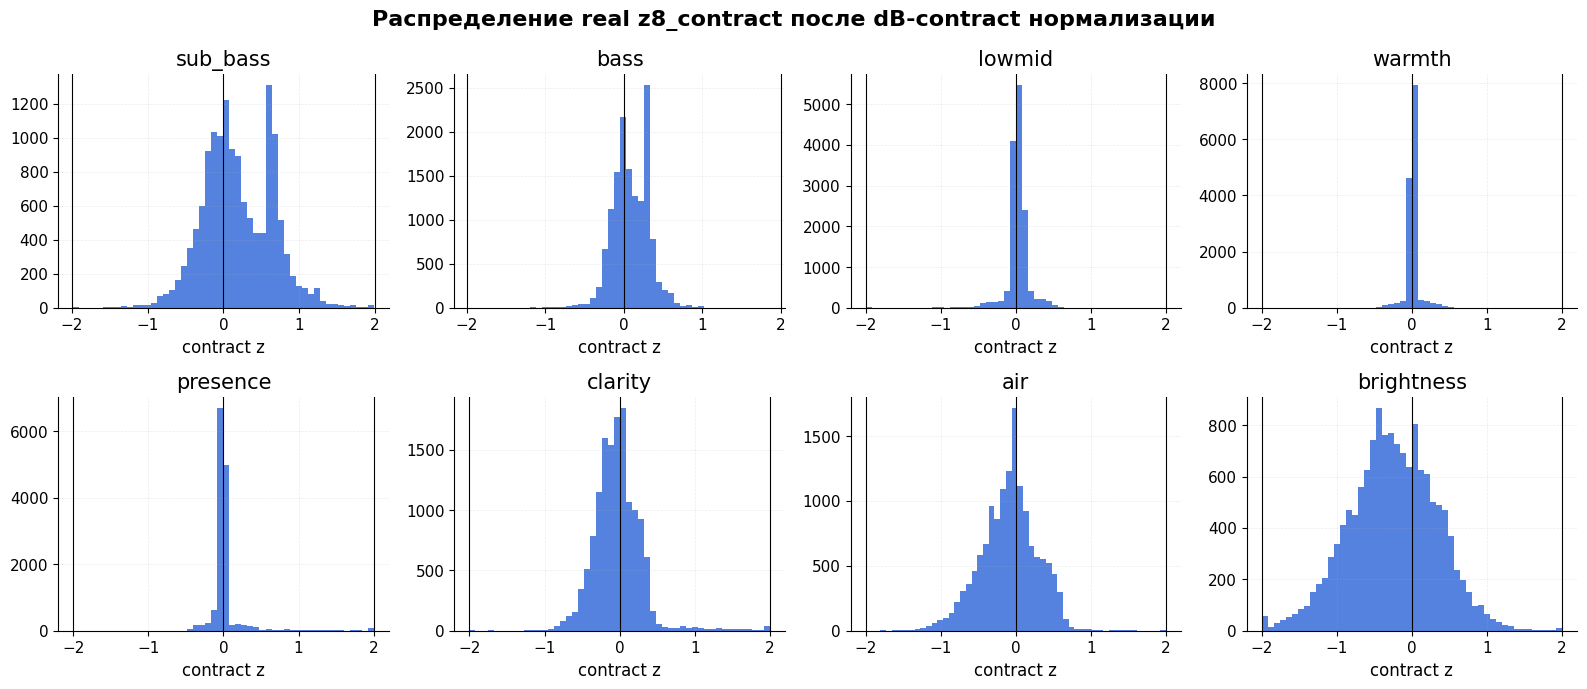

In [11]:
# Histograms for real contract z values.
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes = axes.ravel()
for i, name in enumerate(fs.FEATURE_NAMES_8D):
    ax = axes[i]
    ax.hist(Z_real[:, i], bins=50, alpha=0.85)
    ax.axvline(-2, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.axvline(2, color="black", linewidth=0.8)
    ax.set_title(name)
    ax.set_xlabel("contract z")
fig.suptitle("Распределение real z8_contract после dB-contract нормализации", fontsize=16, fontweight="bold")
fig.tight_layout()
mp.save_current_figure(FIGURES_DIR / "mapper_v4_01_real_contract_z_histograms.png")
plt.show()

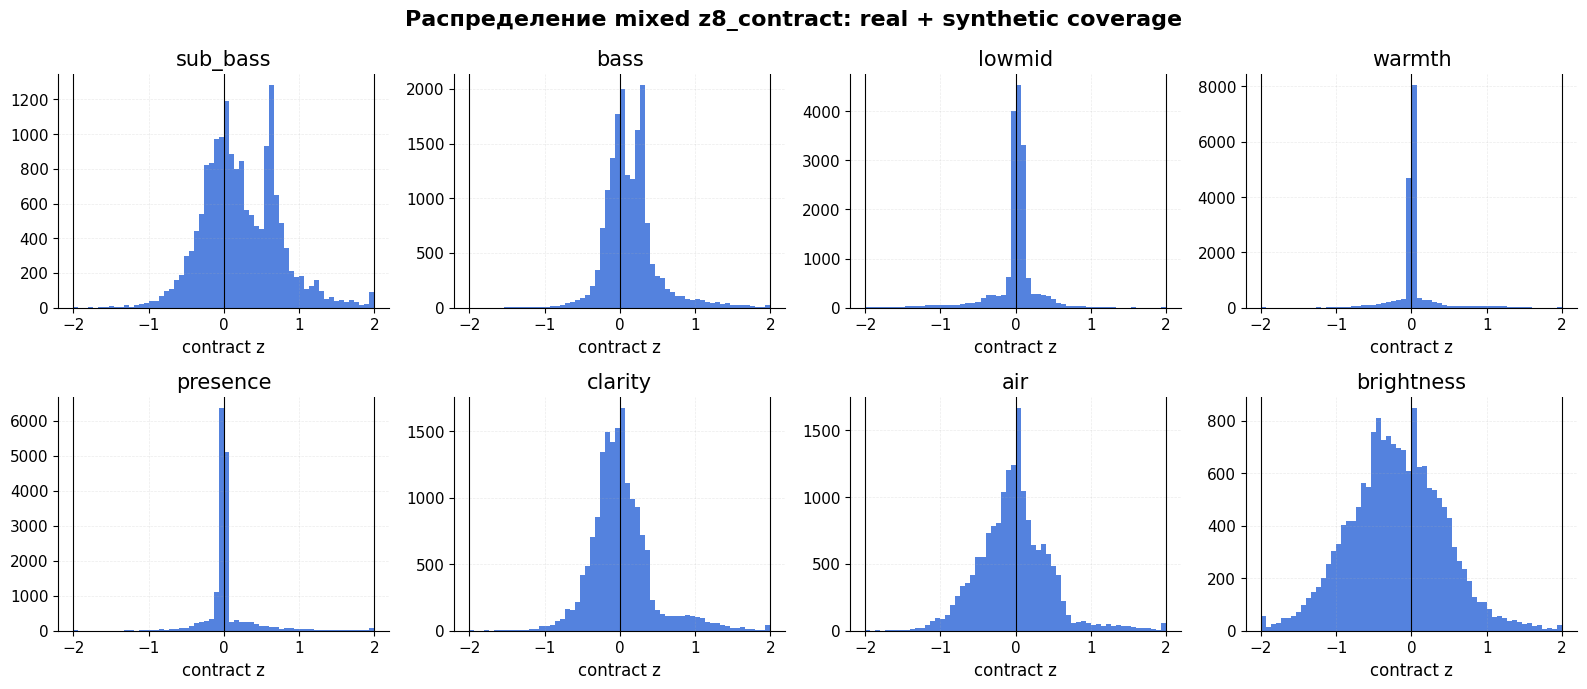

In [12]:
# Histograms for mixed contract z values.
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes = axes.ravel()
for i, name in enumerate(fs.FEATURE_NAMES_8D):
    ax = axes[i]
    ax.hist(Z_mixed[:, i], bins=60, alpha=0.85)
    ax.axvline(-2, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.axvline(2, color="black", linewidth=0.8)
    ax.set_title(name)
    ax.set_xlabel("contract z")
fig.suptitle("Распределение mixed z8_contract: real + synthetic coverage", fontsize=16, fontweight="bold")
fig.tight_layout()
mp.save_current_figure(FIGURES_DIR / "mapper_v4_01_mixed_contract_z_histograms.png")
plt.show()

## 6. Target EQ range by source

Проверяем, что real-часть остаётся реалистичной, а synthetic-часть покрывает сильные/extreme кривые.

In [13]:
range_rows = []
for group, g in mixed_df.groupby("source_group", dropna=False):
    Y = np.stack(g["curve_23"].values).astype(np.float32)
    range_rows.append({
        "source_group": group,
        "rows": len(g),
        "mean_abs_db": float(np.mean(np.abs(Y))),
        "p95_abs_db": float(np.percentile(np.abs(Y), 95)),
        "max_abs_db": float(np.max(np.abs(Y))),
        "mean_max_curve_abs_db": float(np.mean(np.max(np.abs(Y), axis=1))),
    })
range_df = pd.DataFrame(range_rows).sort_values("rows", ascending=False)
range_df.to_csv(TABLES_DIR / "mapper_v4_01_target_range_by_source.csv", index=False)
range_df

,source_group,rows,mean_abs_db,p95_abs_db,max_abs_db,mean_max_curve_abs_db
0,opra,12593,1.097051,5.549853,19.925787,5.302817
3,synthetic_archetype_jitter,2000,4.488358,12.056806,16.000000,9.967907
1,socialfx,1595,0.906375,1.877683,3.459269,1.920107
5,synthetic_random,709,2.908632,8.102938,15.298779,7.661195
4,synthetic_axis,64,1.206174,5.348290,12.605610,5.483063
2,synthetic_archetype,7,4.518878,11.168966,15.045159,9.856592


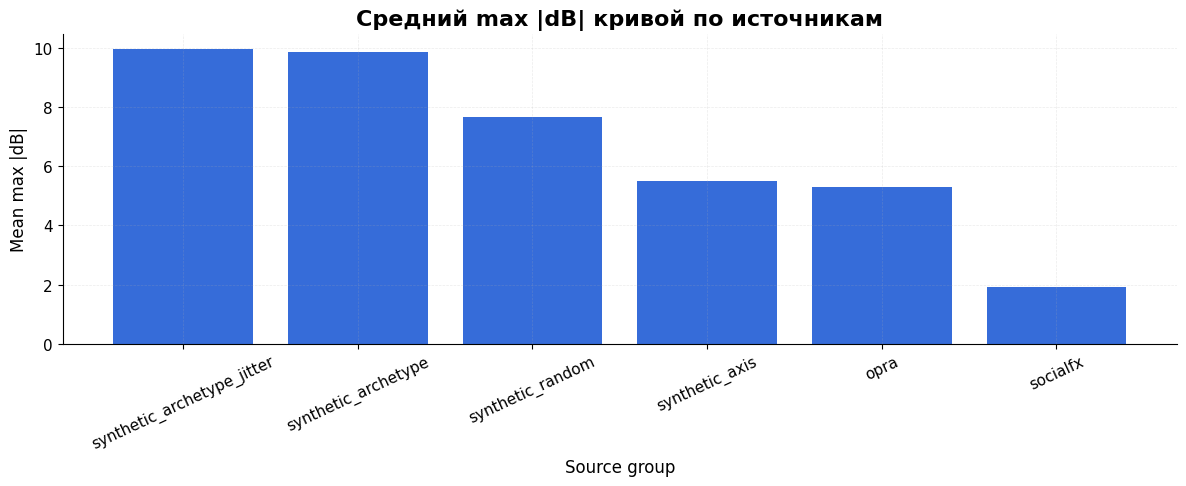

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_df = range_df.sort_values("mean_max_curve_abs_db", ascending=False)
ax.bar(plot_df["source_group"], plot_df["mean_max_curve_abs_db"])
ax.set_title("Средний max |dB| кривой по источникам", fontsize=16, fontweight="bold")
ax.set_ylabel("Mean max |dB|")
ax.set_xlabel("Source group")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
mp.save_current_figure(FIGURES_DIR / "mapper_v4_01_target_range_by_source.png")
plt.show()

## 7. Save dataset for training

Файл сохраняется под старым именем для совместимости с `mapper_v4_03_train_scale_aligned_mapper.ipynb`.

Внутри:

```text
z8_scaled_vector == z8_contract_vector
```

То есть train notebook можно не переписывать: он продолжит читать `z8_scaled_vector`, но теперь это уже правильная contract-шкала.

In [15]:
normalizer_path = OUTPUT_DIR / "mapper_v4_feature_scale_normalizer.json"
dataset_path = OUTPUT_DIR / "mapper_v4_scale_aligned_dataset.parquet"

normalizer.save_json(normalizer_path)

mio.save_curve_dataset_parquet(
    mixed_df,
    dataset_path,
    array_columns=[
        "curve_23",
        "freqs_23",
        "z8_raw_vector",
        "z8_scaled_vector",
        "z8_contract_vector",
    ],
    drop_array_columns=True,
)

source_summary.to_csv(TABLES_DIR / "mapper_v4_01_mixed_source_summary.csv", index=False)
contract_table.to_csv(TABLES_DIR / "mapper_v4_01_contract_extreme_db.csv", index=False)

print("saved dataset:", dataset_path)
print("saved normalizer:", normalizer_path)
print("saved rows:", len(mixed_df))

saved dataset: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\mapper_v4_scale_aligned_dataset.parquet
saved normalizer: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\mapper_v4_feature_scale_normalizer.json
saved rows: 16968


## 8. Quick reload test

Проверяем, что train notebook сможет открыть файл и получить `X=z8_scaled_vector`, `Y=curve_23`.

In [16]:
reloaded, reloaded_freqs = mio.load_curve_dataset(dataset_path)

if "z8_scaled_vector_json" in reloaded.columns:
    reloaded["z8_scaled_vector"] = reloaded["z8_scaled_vector_json"].apply(lambda x: fs.parse_array_value(x, dtype=np.float32))
if "z8_raw_vector_json" in reloaded.columns:
    reloaded["z8_raw_vector"] = reloaded["z8_raw_vector_json"].apply(lambda x: fs.parse_array_value(x, dtype=np.float32))

X_check, Y_check = mio.dataframe_to_training_arrays(reloaded, x_col="z8_scaled_vector", y_col="curve_23")
print("reloaded rows:", len(reloaded))
print("X_check:", X_check.shape, "range", float(X_check.min()), float(X_check.max()))
print("Y_check:", Y_check.shape, "range", float(Y_check.min()), float(Y_check.max()))

pd.DataFrame({
    "check": ["rows", "x_dim", "y_dim"],
    "value": [len(reloaded), X_check.shape[1], Y_check.shape[1]],
})

reloaded rows: 16968
X_check: (16968, 8) range -2.0 2.0
Y_check: (16968, 23) range -19.9257869720459 19.9257869720459


,check,value
0,rows,16968
1,x_dim,8
2,y_dim,23
